In [1]:
%load_ext autoreload
%autoreload 2
import icechunk
import matplotlib.pyplot as plt
import zarr

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid, rechunk
from srm.qaqc import (
    disagg_test_calculate_metrics,
)
import xarray as xr
from srm.utils import open_icechunk

## Get data

In [2]:
path_output = (
    "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
)
var = "DTR"
scenario = "historical"
ens = "r3i1p1f1"
branch = "v0.11.0"

In [4]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm",  # "carbonplan-srm",
    # prefix="srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/",
    prefix="output/production/CESM2-WACCM-ERA5-global.icechunk/",
    region="us-west-2")
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch=branch)
root = zarr.open_group(session.store, mode="r")
print(root.tree())

{'v0.11.0', 'main', 'v0.10.0', 'v0.7.0', 'v0.8.0'}
/
├── debiased_coarse
│   ├── g6_1p5k
│   │   ├── dtr
│   │   │   └── 003
│   │   │       ├── dtr (25568, 192, 288) float32
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       └── time (25568,) int64
│   │   ├── hurs
│   │   │   └── 003
│   │   │       ├── hurs (25568, 192, 288) float32
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       └── time (25568,) int64
│   │   ├── pr
│   │   │   └── 003
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       ├── pr (25568, 192, 288) float32
│   │   │       └── time (25568,) int64
│   │   ├── rsds
│   │   │   └── 003
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       ├── rsds (25568, 192, 288) float32
│   │   │       └── time (25568,) int64
│   │   ├── tas
│   │   │   └── 003
│   │   │       ├── lat (192,) float64
│   │   │       ├─

In [5]:
obs = catalog.get("ERA5").to_xarray()

In [5]:
dtr = (obs.tasmax - obs.tasmin).compute()

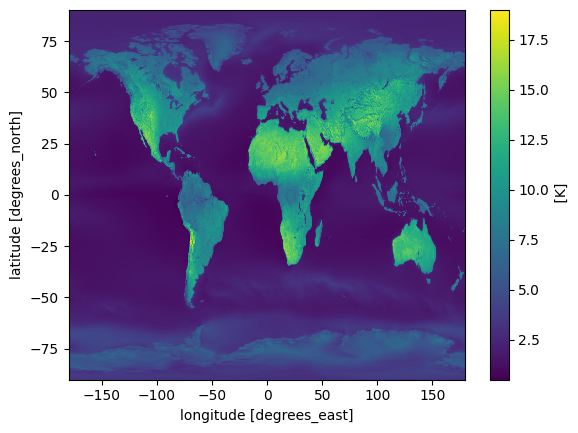

In [7]:
dtr.mean(dim='time').plot()

In [11]:
small_dtr = (dtr<1).sum(dim='time').compute()

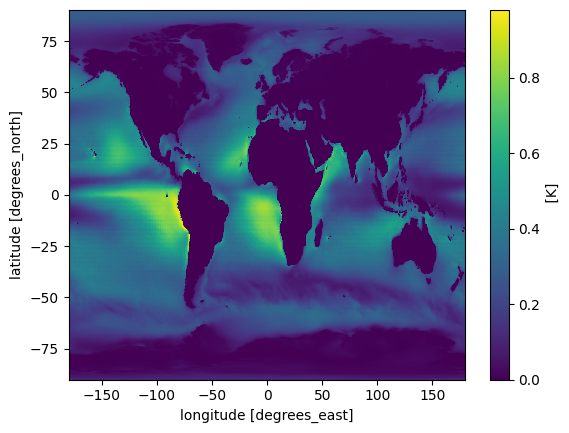

In [13]:
(small_dtr/len(dtr.time.values)).plot()

In [6]:
# subset to region to help with compute - quantile takes a lot!

In [97]:
lat_slice = slice(25, 60)
lon_slice = slice(-125, -70)

In [12]:
obs = obs.sel(lat=lat_slice, lon=lon_slice)
dtr = (obs.tasmax - obs.tasmin).compute()

In [14]:
dtr_q1 = dtr.quantile(0.1, dim='time', skipna=True).compute()

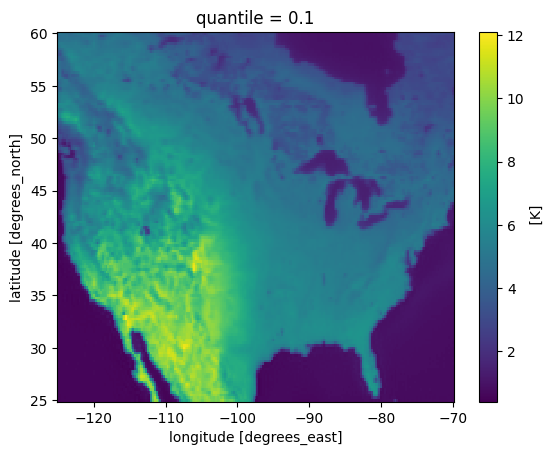

In [16]:
dtr_q1.plot()

# inspecting single location in north america

In [3]:
lat = 38
lon = -90

In [4]:
ens_dict = {'historical': {'tas': 'r3i1p1f1',
                           'tasmax': '001',
                           'tasmin': '001'},
            'g6_1p5k': {'tas': '003',
                        'tasmax': '003',
                        'tasmin': '003'}}

In [5]:
scenario='historical'
downscaled = xr.Dataset()

for var, ens in ens_dict[scenario].items():
    downscaled[var] = open_icechunk(
        path=path_output,
        branch=branch,
        group=scenario + "/" + var + "/" + ens,
    )[var]
downscaled = downscaled.sel(lat=lat, lon=lon)


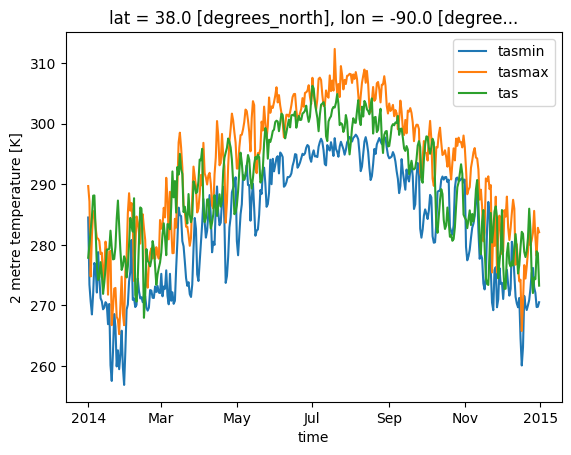

In [6]:
fig, ax = plt.subplots()
year = '2014'
downscaled.sel(time=slice(year, year)).tasmin.plot(ax=ax, label='tasmin')
downscaled.sel(time=slice(year, year)).tasmax.plot(ax=ax, label='tasmax')
downscaled.sel(time=slice(year, year)).tas.plot(ax=ax, label='tas')

plt.legend()

In [7]:
(downscaled.tasmin > downscaled.tas).sum().values/len((downscaled.tasmin.time))

np.float64(0.23405357407133343)

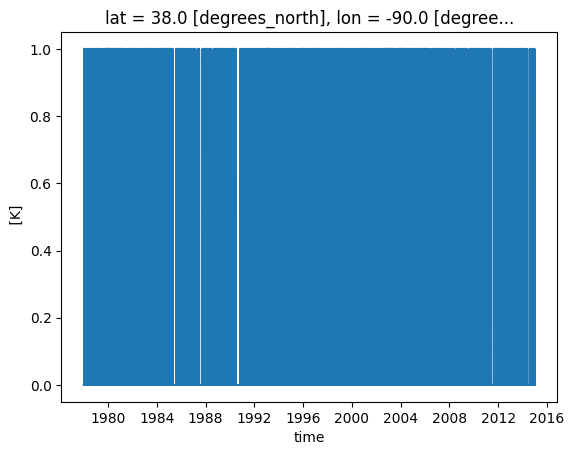

In [8]:
(downscaled.tasmin > downscaled.tas).plot()

In [10]:
tasmin_greater_tas = downscaled.tasmin > downscaled.tas
tasmin_diff_tas = (downscaled.tas-downscaled.tasmin).where(tasmin_greater_tas)#.sum().values/len((downscaled.tasmin.time))

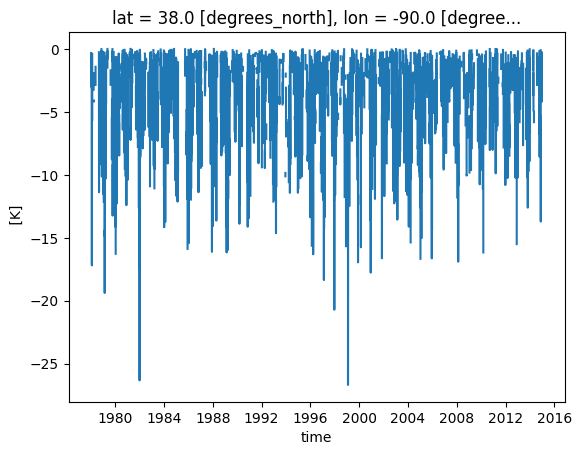

In [28]:
tasmin_diff_tas.plot()

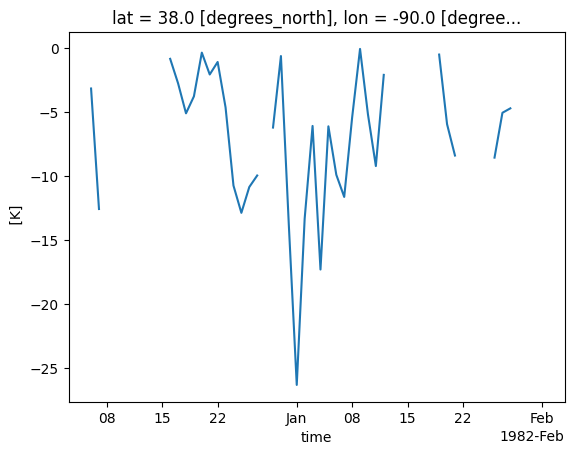

In [37]:
time_slice = slice('1981-12-01', '1982-02-15')
tasmin_diff_tas.sel(time=time_slice).plot()

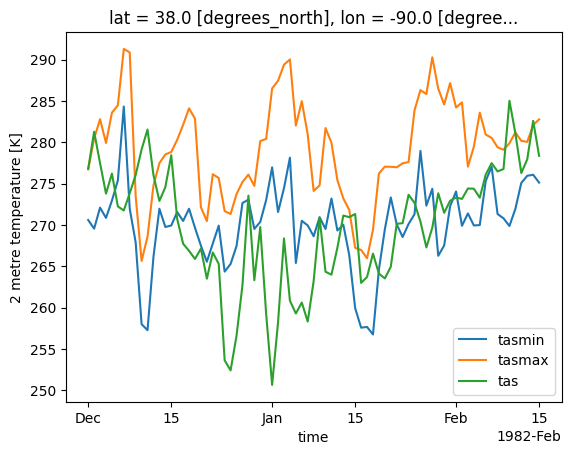

In [38]:
fig, ax = plt.subplots()
downscaled.sel(time=time_slice).tasmin.plot(ax=ax, label='tasmin')
downscaled.sel(time=time_slice).tasmax.plot(ax=ax, label='tasmax')
downscaled.sel(time=time_slice).tas.plot(ax=ax, label='tas')

plt.legend()

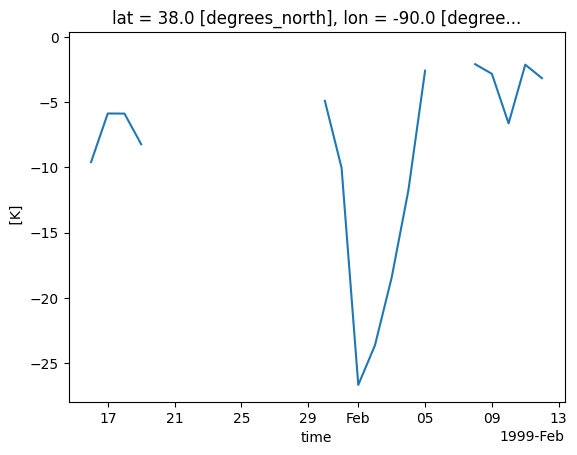

In [25]:
time_slice = slice('1999-01-15', '1999-02-15')
tasmin_diff_tas.sel(time=time_slice).plot()

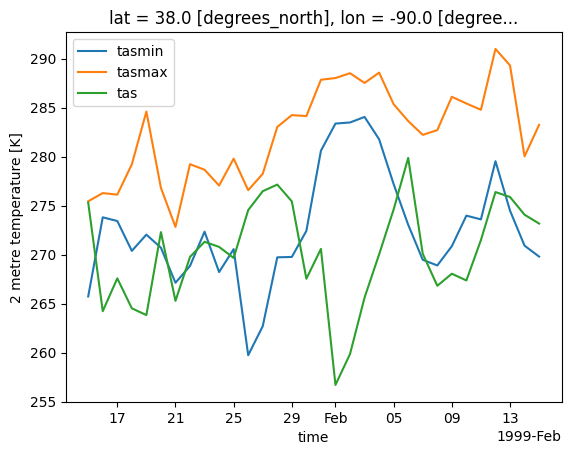

In [26]:
fig, ax = plt.subplots()
downscaled.sel(time=time_slice).tasmin.plot(ax=ax, label='tasmin')
downscaled.sel(time=time_slice).tasmax.plot(ax=ax, label='tasmax')
downscaled.sel(time=time_slice).tas.plot(ax=ax, label='tas')

plt.legend()

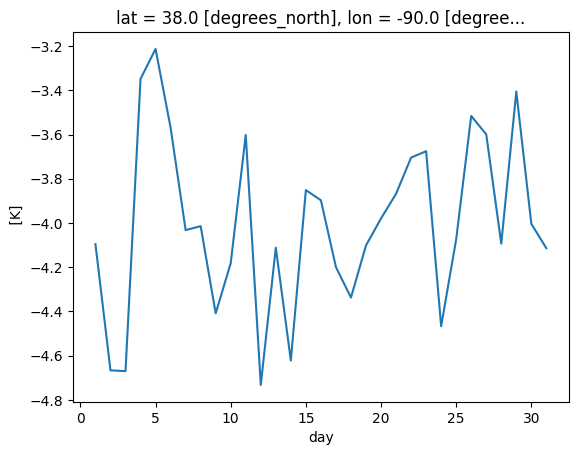

In [24]:
tasmin_diff_tas.groupby('time.day').mean().plot()

In [39]:
scenario='g6_1p5k'
downscaled = xr.Dataset()

for var, ens in ens_dict[scenario].items():
    downscaled[var] = open_icechunk(
        path=path_output,
        branch=branch,
        group=scenario + "/" + var + "/" + ens,
    )[var]
downscaled = downscaled.sel(lat=lat, lon=lon)


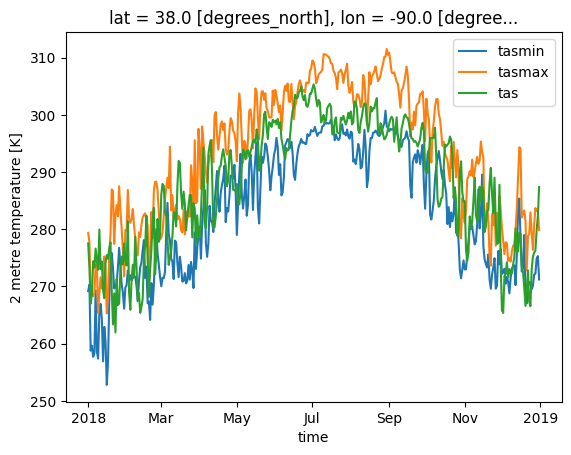

In [90]:
fig, ax = plt.subplots()
year = '2018'
downscaled.sel(time=slice(year, year)).tasmin.plot(ax=ax, label='tasmin')
downscaled.sel(time=slice(year, year)).tasmax.plot(ax=ax, label='tasmax')
downscaled.sel(time=slice(year, year)).tas.plot(ax=ax, label='tas')

plt.legend()

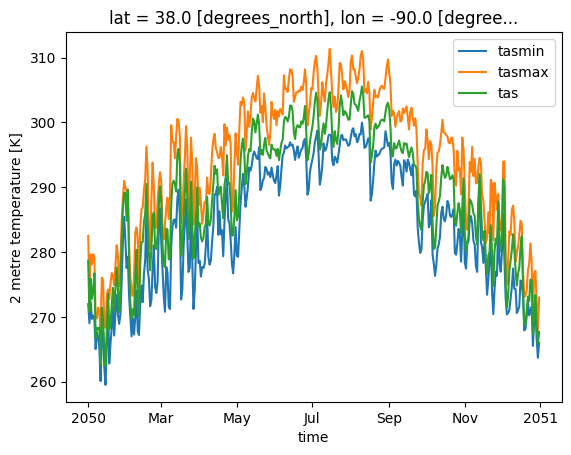

In [91]:
fig, ax = plt.subplots()
year = '2050'
downscaled.sel(time=slice(year, year)).tasmin.plot(ax=ax, label='tasmin')
downscaled.sel(time=slice(year, year)).tasmax.plot(ax=ax, label='tasmax')
downscaled.sel(time=slice(year, year)).tas.plot(ax=ax, label='tas')

plt.legend()

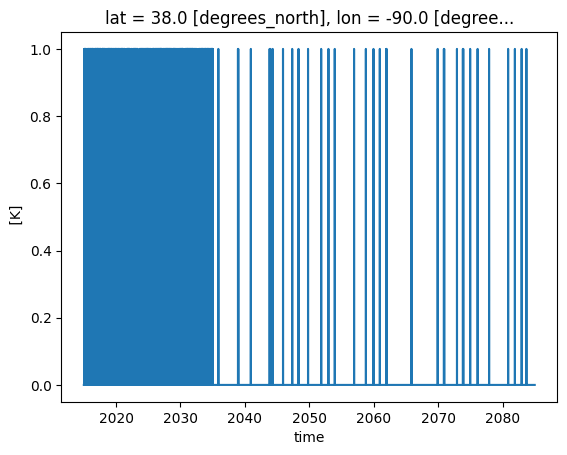

In [92]:
(downscaled.tasmin > downscaled.tas).plot()

In [93]:
(downscaled.tasmin > downscaled.tas).sum().values/len((downscaled.tasmin.time))

np.float64(0.06367334167709637)

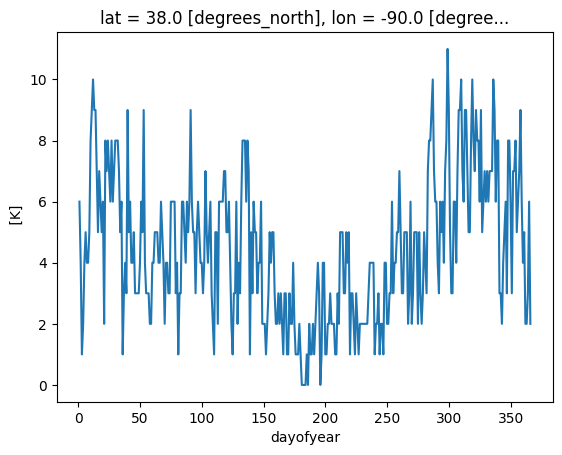

In [94]:
(downscaled.tasmin > downscaled.tas).groupby('time.dayofyear').sum().plot()

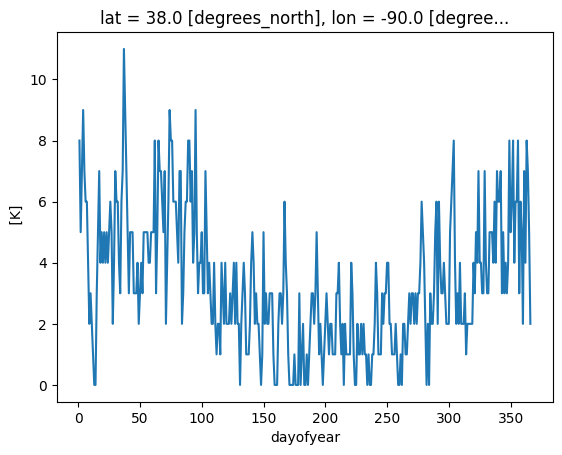

In [95]:
(downscaled.tasmax < downscaled.tas).groupby('time.dayofyear').sum().plot()

In [40]:
# now where is the tasmax less than the tasmin, though that is expected by construction because any instances of that behavior is fixed with a swapped at the end of the process.

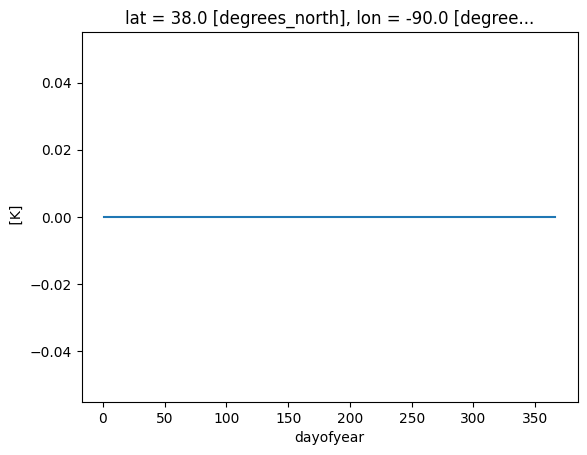

In [96]:
(downscaled.tasmax < downscaled.tasmin).groupby('time.dayofyear').sum().plot()

In [41]:
scenario='g6_1p5k'
debiased_coarse = xr.Dataset()

for var, ens in ens_dict[scenario].items():
    debiased_coarse[var] = open_icechunk(
        path=path_output,
        branch=branch,
        group='debiased_coarse'+ "/" + scenario + "/" + var + "/" + ens,
    )[var]

In [42]:
# the debiased tasmax is never less than tasmin. any instances of it get introduced by the disaggregation.

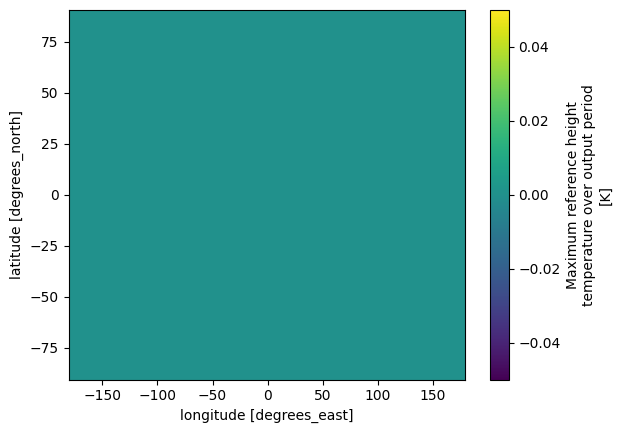

In [43]:
(debiased_coarse.tasmax < debiased_coarse.tasmin).sum(dim='time').plot()

Text(0.5, 1.0, '% of time when coarse debiased tasmax is less than tas')

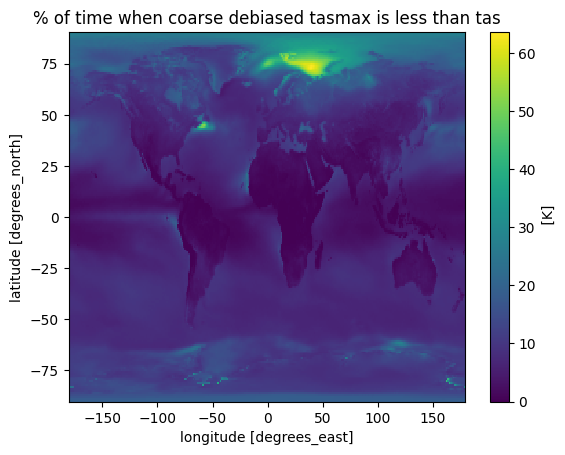

In [44]:
((debiased_coarse.tasmax < debiased_coarse.tas).sum(dim='time')/len(debiased_coarse.tas.time) * 100).plot()
plt.title('% of time when coarse debiased tasmax is less than tas')

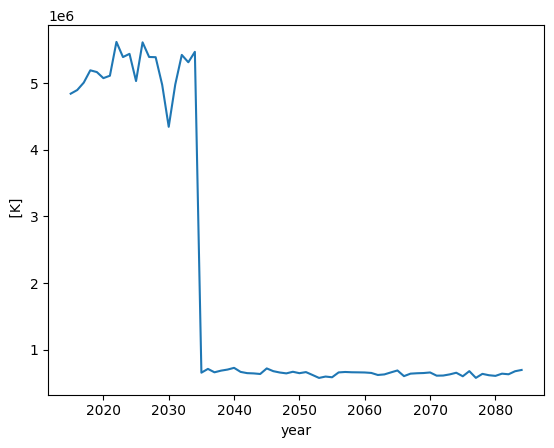

In [45]:
((debiased_coarse.tasmax < debiased_coarse.tas).sum(dim=['lat', 'lon']).groupby('time.year').sum()).plot()

In [46]:
tasmin_greater_tas = debiased_coarse.tasmin > debiased_coarse.tas
tasmin_diff_tas = (debiased_coarse.tas-debiased_coarse.tasmin).where(tasmin_greater_tas)#.sum().values/len((downscaled.tasmin.time))

In [50]:
# any instances of the tasmin being greater than tas for one pixel are limited to ~1 degree for the time range when they are from the same scenario.

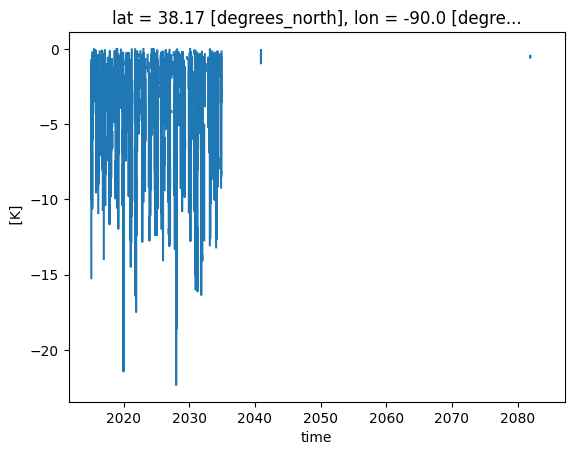

In [49]:
tasmin_diff_tas.sel(lat=lat, lon=lon, method='nearest').plot()

In [58]:
scenario='g6_1p5k'
downscaled = xr.Dataset()

for var, ens in ens_dict[scenario].items():
    downscaled[var] = open_icechunk(
        path=path_output,
        branch=branch,
        group=scenario + "/" + var + "/" + ens,
    )[var]
downscaled = downscaled.sel(lat=lat, lon=lon, method='nearest')

tasmin_greater_tas = downscaled.tasmin > downscaled.tas
tasmin_diff_tas = (downscaled.tas-downscaled.tasmin).where(tasmin_greater_tas)#.sum().values/len((downscaled.tasmin.time))

In [60]:
# the downscaling introduces 1 extra day when tasmin is greater than tas

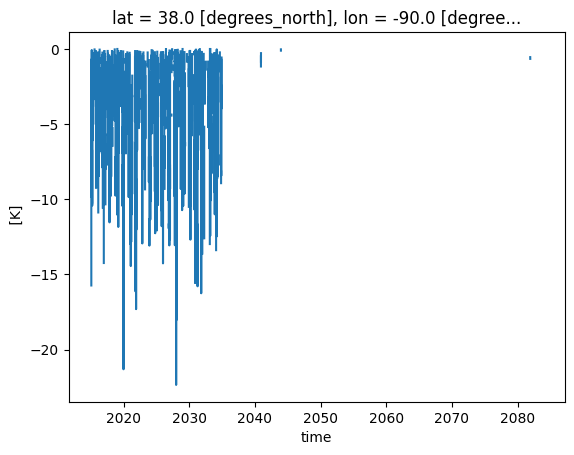

In [59]:
tasmin_diff_tas.plot()